In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.scripts.variable_profiling import eda_per_table_printing_results
from default_risk.scripts.variable_profiling import eda_per_table_persisting_result_html
from default_risk.scripts.variable_profiling import create_files_nulls_per_colmun
from default_risk.scripts.auxiliar_eda_function import recreate_and_sort_series_given_rows
from default_risk.scripts.auxiliar_eda_function import recreate_and_sort_the_serie_given_ids
from default_risk.scripts.auxiliar_eda_function import check_invariant
import default_risk.config as cfg
import dtale
import dtale.global_state as dtale_global
import logging

dtale_global.cleanup()

previous_application_df = pd.read_csv(cfg.PREVIOUS_APPLICATION)

data_frame_size=len(previous_application_df)

log = logging.getLogger('werkzeug')


with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)

Invariants found at the moment: (# number of cell with the proofs and relevant code)


1- There is not duplicated ids, therefore, diferent applications for same contract have diferent prev_id. (100%) #1

2- If a application are marked as "no final" (FLAG_LAST_APPL_PER_CONTRACT == N), the status can not be approved ("NAME_CONTRACT_STATUS" != "Approved") (100%) #4


Soft constraints:  

1- Missing values alignment: If AMT_ANNUITY is missing CNT_PAYMENT is also missing (99.99%) #8
    anomalies: instances of data corruption. 


Decisions summary:

1- Based on the soft constraint #1, we will drop the rows where the missing values of AMT_ANNUITY and CNT_PAYMENT are not aligned (not nan simultaneously)

2- We will conserve the contracts marked as no final (FLAG_LAST_APPL_PER_CONTRACT == N) with the intention to extract features later, but we will ignore it to any aggregation metrics
    in order of don't count twice the same contract. 

3- A set of columns have a sentinel value  "365243" (for instance: DAYS_FIRST_DRAWING, DAYS_FIRST_DUE among others), but these sentinels value are not aligned. So we will create
    a flag for each column individually for these values #9



In [ ]:
#files for the data dictionary
create_files_nulls_per_colmun(previous_application_df,"previous_application")

In [6]:
eda_per_table_printing_results(previous_application_df,schema,"previous_application",False)

--------------------------------------
SK_ID_PREV
basic_data


,cardinality,mode
0,1670214,"[1000001, 1000002, 1000003, 1000004, 1000005, ..."


frequency


,CATEGORY,COUNT,SEGMENT
0,2030495,1,top
1,1035848,1,top
2,1526498,1,top
3,2148893,1,top
4,2437429,1,top
5,1624541,1,top
6,2095602,1,top
7,1203077,1,top
8,2842426,1,top
9,1758596,1,top


--------------------------------------
SK_ID_CURR
basic_data


...

,skew,p90,p99,ratio_p99_p50,ratio_p99_p90,ratio_max_value_p99
0,1.306376,365243.0,365243.0,-731.9499,1.0,1.0


--------------------------------------
NFLAG_INSURED_ON_APPROVAL
basic_data


,cardinality,mode
0,3,[0.0]


frequency


,CATEGORY,COUNT,SEGMENT
0,NaN,673065,full
1,0.0,665527,full
2,1.0,331622,full


In [ ]:
"""in the column of "FLAG_LAST_APPL_PER_CONTRACT" the description says: "Flag if it was last application for the previous contract. 
Sometimes by mistake of client or our clerk there could be more applications for one single contract, so i'm going to look for that potential errors"""

In [ ]:
previous_application_df["FLAG_LAST_APPL_PER_CONTRACT"].head()

In [ ]:
#1
#there is no dups with SK_ID_PREV. si the check would be based per client because the description don't mention how a dup looks like.
previous_application_df.groupby("SK_ID_PREV").size().max()

In [ ]:
#2
boolean_mask_for_flag= previous_application_df["FLAG_LAST_APPL_PER_CONTRACT"] == "Y"
clients_ids_more_than_one_flaged_as_final= boolean_mask_for_flag.groupby(previous_application_df["SK_ID_CURR"]).sum().loc[lambda g : g  > 1].index
rows_of_client_with_more_than_one=previous_application_df[previous_application_df["SK_ID_CURR"].isin(clients_ids_more_than_one_flaged_as_final)]
rows_of_client_with_more_than_one.head()
len(rows_of_client_with_more_than_one)

#and seems like have more than 1 previous application flagged as final is the most usual scenario.

In [ ]:
#3
#so, the idea is check if the next solicitud of the same client, after a contract with that flag in "N", is similar. And that would be the "duplicates".
previous_application_df.sort_index
boolean_mask_for_flag_in_negative= previous_application_df["FLAG_LAST_APPL_PER_CONTRACT"] == "N" 
rows_applications_no_final= previous_application_df[boolean_mask_for_flag_in_negative] 
ids=rows_applications_no_final["SK_ID_CURR"]
ids_cutted= ids[:20]
clients_with_at_leas_a_no_final=previous_application_df[previous_application_df["SK_ID_CURR"].isin(ids_cutted)]
clients_with_at_leas_a_no_final.sort_values(["SK_ID_CURR","DAYS_DECISION"]).to_csv(cfg.DUMP_FROM_NOTEBOOKS /"pairs.csv")
dtale.show(clients_with_at_leas_a_no_final.sort_values(["SK_ID_CURR","DAYS_DECISION"]))
#in this manual check using dtale, i found that not always the applications flaged as no final have a re try but has been discover that have a very high correlation with rejection.
#so we will investigate they correlation with rejection and if treat it like a subset of rejection o two different sets.


In [ ]:
#4
mask_not_last_in_day= previous_application_df["FLAG_LAST_APPL_PER_CONTRACT"] == "N" 
no_final= previous_application_df[mask_not_last_in_day] 
no_final_approved= no_final[no_final["NAME_CONTRACT_STATUS"] == "Approved"]
print(len(no_final_approved))
print(len(rows_applications_no_final) - len(no_final_approved)) 
dtale.show(rows_applications_no_final)
#Evidence of non existence a contract marked as not final and approved.

In [ ]:
#5
mask_not_last_in_day= previous_application_df["NFLAG_LAST_APPL_IN_DAY"] == 0 
not_last_in_day_rows= previous_application_df[mask_not_last_in_day] 
one_flag_subset_of_another= (not_last_in_day_rows["FLAG_LAST_APPL_PER_CONTRACT"] == "Y").sum()
no_final_approved= (not_last_in_day_rows["NAME_CONTRACT_STATUS"] == "Approved")
print("with NFLAG_LAST_APPL_IN_DAY in 1 and approved: " + str(no_final_approved.sum()))
print("With flag NFLAG_LAST_APPL_IN_DAY in 1 and FLAG_LAST_APPL_PER_CONTRACT with Y: " + str(one_flag_subset_of_another))
not_last_in_day_rows[no_final_approved].head()

#so, there is cases where is not the last aplication of the day (NFLAG_LAST_APPL_IN_DAY == 0) but was the last one for the contract ("FLAG_LAST_APPL_PER_CONTRACT"] == "Y").
#And also cases where is not te last application of the day and the contract was "Approved".
#that means, one row are not subset of another, and seems the cases where the client apply for 2 diferents contracts in the same day.

In [15]:
#6
mask_not_last_in_day= previous_application_df["FLAG_LAST_APPL_PER_CONTRACT"] == "N" 
no_final= previous_application_df[mask_not_last_in_day]
no_final_and_no_refused= no_final[no_final["NAME_CONTRACT_STATUS"] != "Refused"]
print(len(no_final_and_no_refused))
no_final_and_no_refused["NAME_CONTRACT_STATUS"].head()




2


502618     Canceled
1028937    Canceled
Name: NAME_CONTRACT_STATUS, dtype: object

"""so, every contract with that flag are marked as "refused" with exception of this 2, marked as canceled. So this provide enough evidence to treat
the rows with that flag as a subset of "refused" contract. The intention is create aggregation metrics of rejected contracts to modelate the diferences between 
the contracts that are approved to the client and the one that are refused. But in the visualization order by DAYS_DECISION seems like almost always there is a another application, similar to the one marked
as not final. So we can assume that if "FLAG_LAST_APPL_PER_CONTRACT" == "N" is a rejected contract and the client tried again with anothers numbers (you can see how sometimes re-apply with a smaller loan) or just
an error marked as refused. Would be interesting catch the diference when are legit retries and one are acepted and the other one no, but otherwise you are catching the same rejection twice, so we are not
dropping this as dups but are not directly used for agg metrics."""

In [12]:
#7
#in early analisis we detect a potencial incosistency in data
incosistency_mask= (previous_application_df["NAME_CONTRACT_STATUS"] == "Refused") & (previous_application_df["CODE_REJECT_REASON" ] == "XAP")
rows_flaged_as_refused_with_no_reason= previous_application_df[incosistency_mask]
rows_flaged_as_refused_with_no_reason.head()
#but is not final ("FLAG_LAST_APPL_PER_CONTRACT" == "N"). So, will not affect nothing let it in the dataset. 

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
887093,1681151,263811,Revolving loans,15750.0,0.0,225000.0,NaN,NaN,TUESDAY,14,...,XNA,0.0,XNA,Card X-Sell,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#8
#during the construction of data dictionary we detect almost perfect correlation between the missing values in AMT_ANNUITY and CNT_PAYMENT so we decide to check for exceptions. 
#in further investigations we found that annuity and cnt_payment are relationaned by a formula, so the expectable is both being null at the same time, and being a "Consumer loan" we can't figure out
#other explaniation than data corruption, so, in order to maintain the data integrity, we decide to drop it. 
mask_same_nulls= (previous_application_df["AMT_ANNUITY"].isnull()) & (previous_application_df["CNT_PAYMENT"].notna())
check_invariant(mask_same_nulls,"the nulls of NAME_CONTRACT_STATUS and CODE_REJECT_REASON, are not aligned",data_frame_size)
previous_application_df[mask_same_nulls].head(10) 

0 of cases where the nulls of NAME_CONTRACT_STATUS and CODE_REJECT_REASON, are not aligned
that represent a 0.0% of cases with violation of this invariant 



,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL


In [ ]:
#9
cols_with_sentinels= ["DAYS_FIRST_DRAWING","DAYS_FIRST_DUE","DAYS_LAST_DUE_1ST_VERSION","DAYS_LAST_DUE","DAYS_TERMINATION"]

rows_with_only_one_field_with_sentinel = (previous_application_df[cols_with_sentinels].eq(365243).sum(axis=1)== 1)

rows_with_only_one_field_with_sentinel.sum()

0.03623667386334925
SELLERPLACE_AREA
-1       762675
 0        60523
 50       37401
 30       34423
 20       33840
 100      31409
 40       24429
 25       18142
 15       17175
 150      16652
 10       16523
 5        14942
 200      12819
 4        12797
 1000     12589
 60       10943
 35       10468
 1500      9887
 300       9308
 2000      8723
 45        8487
 80        8029
 70        7881
 6         7411
 500       6335
 32        5547
 3         5472
 1         5275
 1200      4864
 250       4696
Name: count, dtype: int64


<Axes: xlabel='SELLERPLACE_AREA', ylabel='Count'>

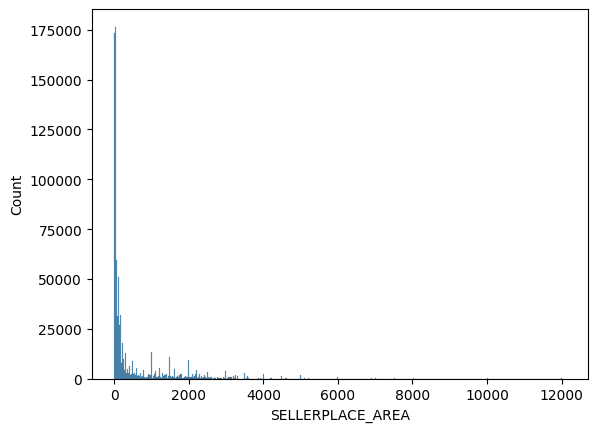

In [ ]:
#10
#we want to check if our hipotesis of encoded values in this variable is true. So in order to discover that we want to analyze the distribution
column= previous_application_df["SELLERPLACE_AREA"]

print((column == 0).mean())
print(column.value_counts().head(30))

q99= column.quantile(0.999)
q01= column.quantile(0.001)

column_cliped=column[(column < q99) & (column > 1)]
sns.histplot(column_cliped, bins= 500)

#it's clear that -1 and 0 have special meaning and the variable have strong preference for rounded numbers, the values and their respective frecuence resemble more with a
#set of estimations made by eye than exact messures.   

In [ ]:
#11
previous_application_df[(previous_application_df["RATE_DOWN_PAYMENT"] < 0) & (previous_application_df["AMT_DOWN_PAYMENT"] < 0)].head(5)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
368107,1284109,350530,Consumer loans,7866.090,71580.60,71581.5,-0.90,71580.60,SATURDAY,13,...,Connectivity,10.0,low_normal,POS mobile without interest,365243.0,-459.0,-189.0,-189.0,-185.0,0.0
1519595,1817983,133068,Consumer loans,3595.545,32719.05,32719.5,-0.45,32719.05,SUNDAY,13,...,Connectivity,10.0,low_normal,POS mobile without interest,365243.0,-430.0,-160.0,-430.0,-415.0,0.0
